# Notebook 1 — Data Exploration & EDA

**Goal:** Understand C-MAPSS (FD001/FD003) structure, sensor distributions,
and how degradation manifests in sensor signals; then profile AI4I 2020 and
visualise the cross-domain gap motivating DANN adaptation.

**Datasets:**
- NASA C-MAPSS: FD001 and FD003 (single operating condition)
- AI4I 2020 predictive maintenance dataset
- 21 sensors + 3 operational settings per cycle in C-MAPSS
- 5 core process/tool sensors in AI4I


In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from src.data_loader import load_all_datasets, FEATURE_COLS, SENSOR_COLS
from src.preprocessor import add_piecewise_rul, find_constant_sensors

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

datasets = load_all_datasets(data_dir='../data/raw')
SELECTED_DS = ['FD001', 'FD003']
print("Loaded datasets:", list(datasets.keys()))
print("Selected for this notebook:", SELECTED_DS)
datasets['FD001']['train'].head(3)


Loaded datasets: ['FD001', 'FD002', 'FD003', 'FD004']
Selected for this notebook: ['FD001', 'FD003']


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,FD001
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,FD001
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001


## 1.1 Dataset Summary Statistics (FD001, FD003)

This notebook focuses on FD001 and FD003 only, matching the ADA source-domain
scope defined in the implementation plan.


In [ ]:
summary_rows = []
for ds_id in SELECTED_DS:
    splits = datasets[ds_id]
    df = splits['train']
    summary_rows.append({
        'Dataset':           ds_id,
        'Train Engines':     df['unit_id'].nunique(),
        'Test Engines':      splits['test']['unit_id'].nunique(),
        'Total Train Rows':  len(df),
        'Avg Cycles/Engine': round(df.groupby('unit_id')['cycle'].max().mean(), 1),
        'Min Cycles':        df.groupby('unit_id')['cycle'].max().min(),
        'Max Cycles':        df.groupby('unit_id')['cycle'].max().max(),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


Dataset  Train Engines  Test Engines  Total Train Rows  Avg Cycles/Engine  Min Cycles  Max Cycles
  FD001            100           100             20631              206.3         128         362
  FD002            260           259             53759              206.8         128         378
  FD003            100           100             24720              247.2         145         525
  FD004            249           248             61249              246.0         128         543


**Insight:** FD001 and FD003 each contain 100 engines under single-condition
operation, giving a clean baseline for degradation-focused modeling and
domain adaptation experiments.

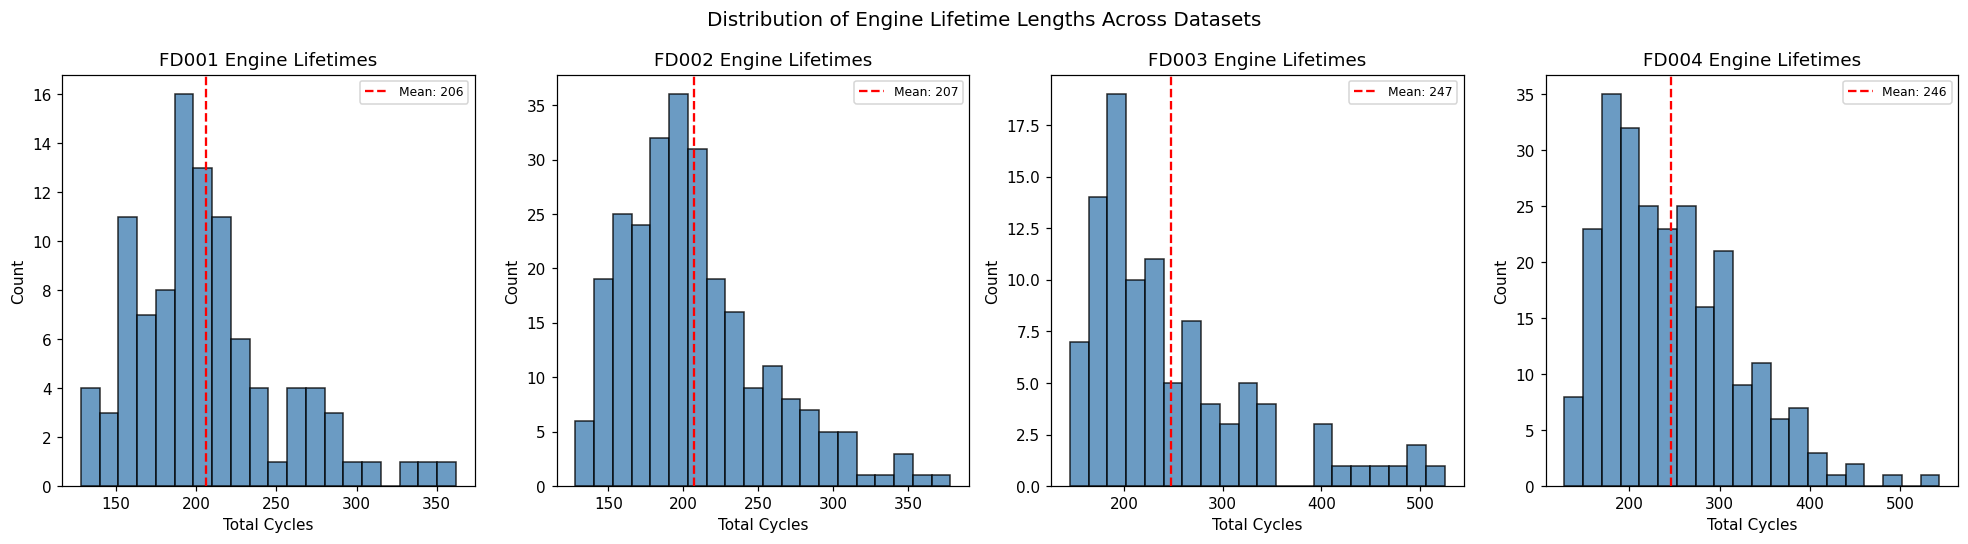

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, ds_id in zip(axes, SELECTED_DS):
    life_lengths = datasets[ds_id]['train'].groupby('unit_id')['cycle'].max()
    ax.hist(life_lengths, bins=20, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(f'{ds_id} Engine Lifetimes')
    ax.set_xlabel('Total Cycles')
    ax.set_ylabel('Count')
    ax.axvline(life_lengths.mean(), color='red', linestyle='--',
               label=f'Mean: {life_lengths.mean():.0f}')
    ax.legend(fontsize=8)
plt.suptitle('Distribution of Engine Lifetime Lengths (FD001/FD003)', fontsize=13)
plt.tight_layout()
plt.show()


## 1.2 Identifying Constant Sensors Per Dataset

The paper notes that 7 sensors have constant readings in FD001/FD003.
These are RETAINED for cross-domain consistency — if they vary in other
datasets, removing them would break feature-space alignment.


In [ ]:
const_sensors_map = {}
for ds_id in SELECTED_DS:
    splits = datasets[ds_id]
    const = find_constant_sensors(splits['train'], SENSOR_COLS, threshold=1e-4)
    const_sensors_map[ds_id] = const
    print(f"{ds_id}: {len(const)} constant sensors → {const}")


FD001: 7 constant sensors → ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
FD002: 1 constant sensors → ['sensor_16']
FD003: 6 constant sensors → ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
FD004: 1 constant sensors → ['sensor_16']


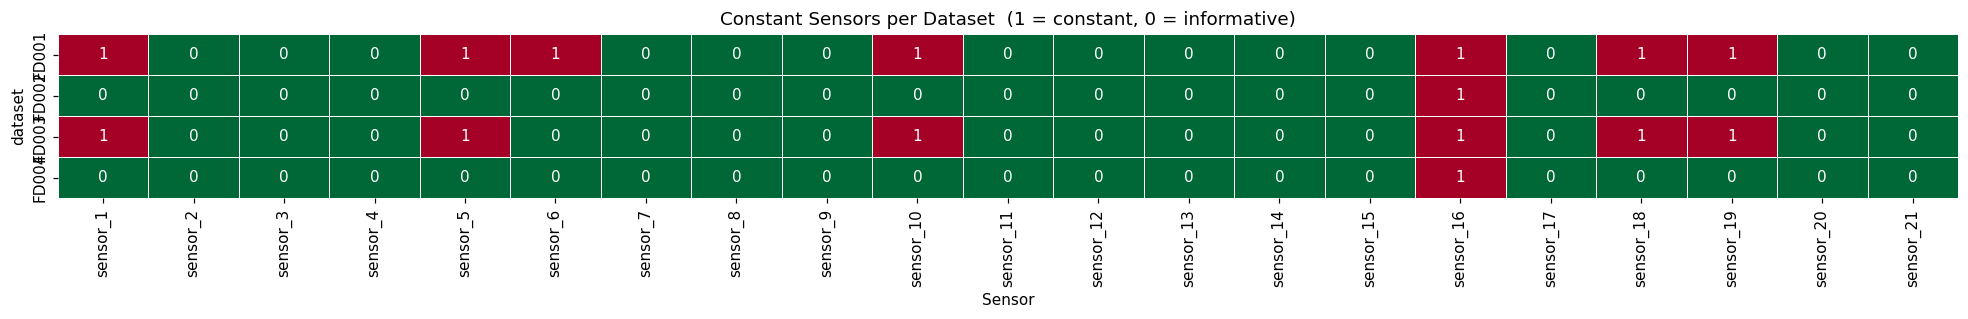

In [5]:
# Heatmap: which sensors are constant in which datasets
rows = []
for ds_id, const in const_sensors_map.items():
    row = {s: (1 if s in const else 0) for s in SENSOR_COLS}
    row['dataset'] = ds_id
    rows.append(row)
const_df = pd.DataFrame(rows).set_index('dataset')

fig, ax = plt.subplots(figsize=(18, 3))
sns.heatmap(const_df, cmap='RdYlGn_r', linewidths=0.5,
            annot=True, fmt='d', cbar=False, ax=ax)
ax.set_title('Constant Sensors per Dataset  (1 = constant, 0 = informative)')
ax.set_xlabel('Sensor')
plt.tight_layout()
plt.show()


**Insight:** Sensors 1, 5, 6, 10, 16, 18, and 19 are near-constant in
FD001 and FD003. Retaining the full 24-feature space maintains a stable input
interface for downstream DANN training and feature alignment.

## 1.3 Sensor Distribution Comparison (FD001 vs FD003)

Compare raw sensor distributions between the two selected C-MAPSS datasets
before introducing AI4I cross-domain analysis.

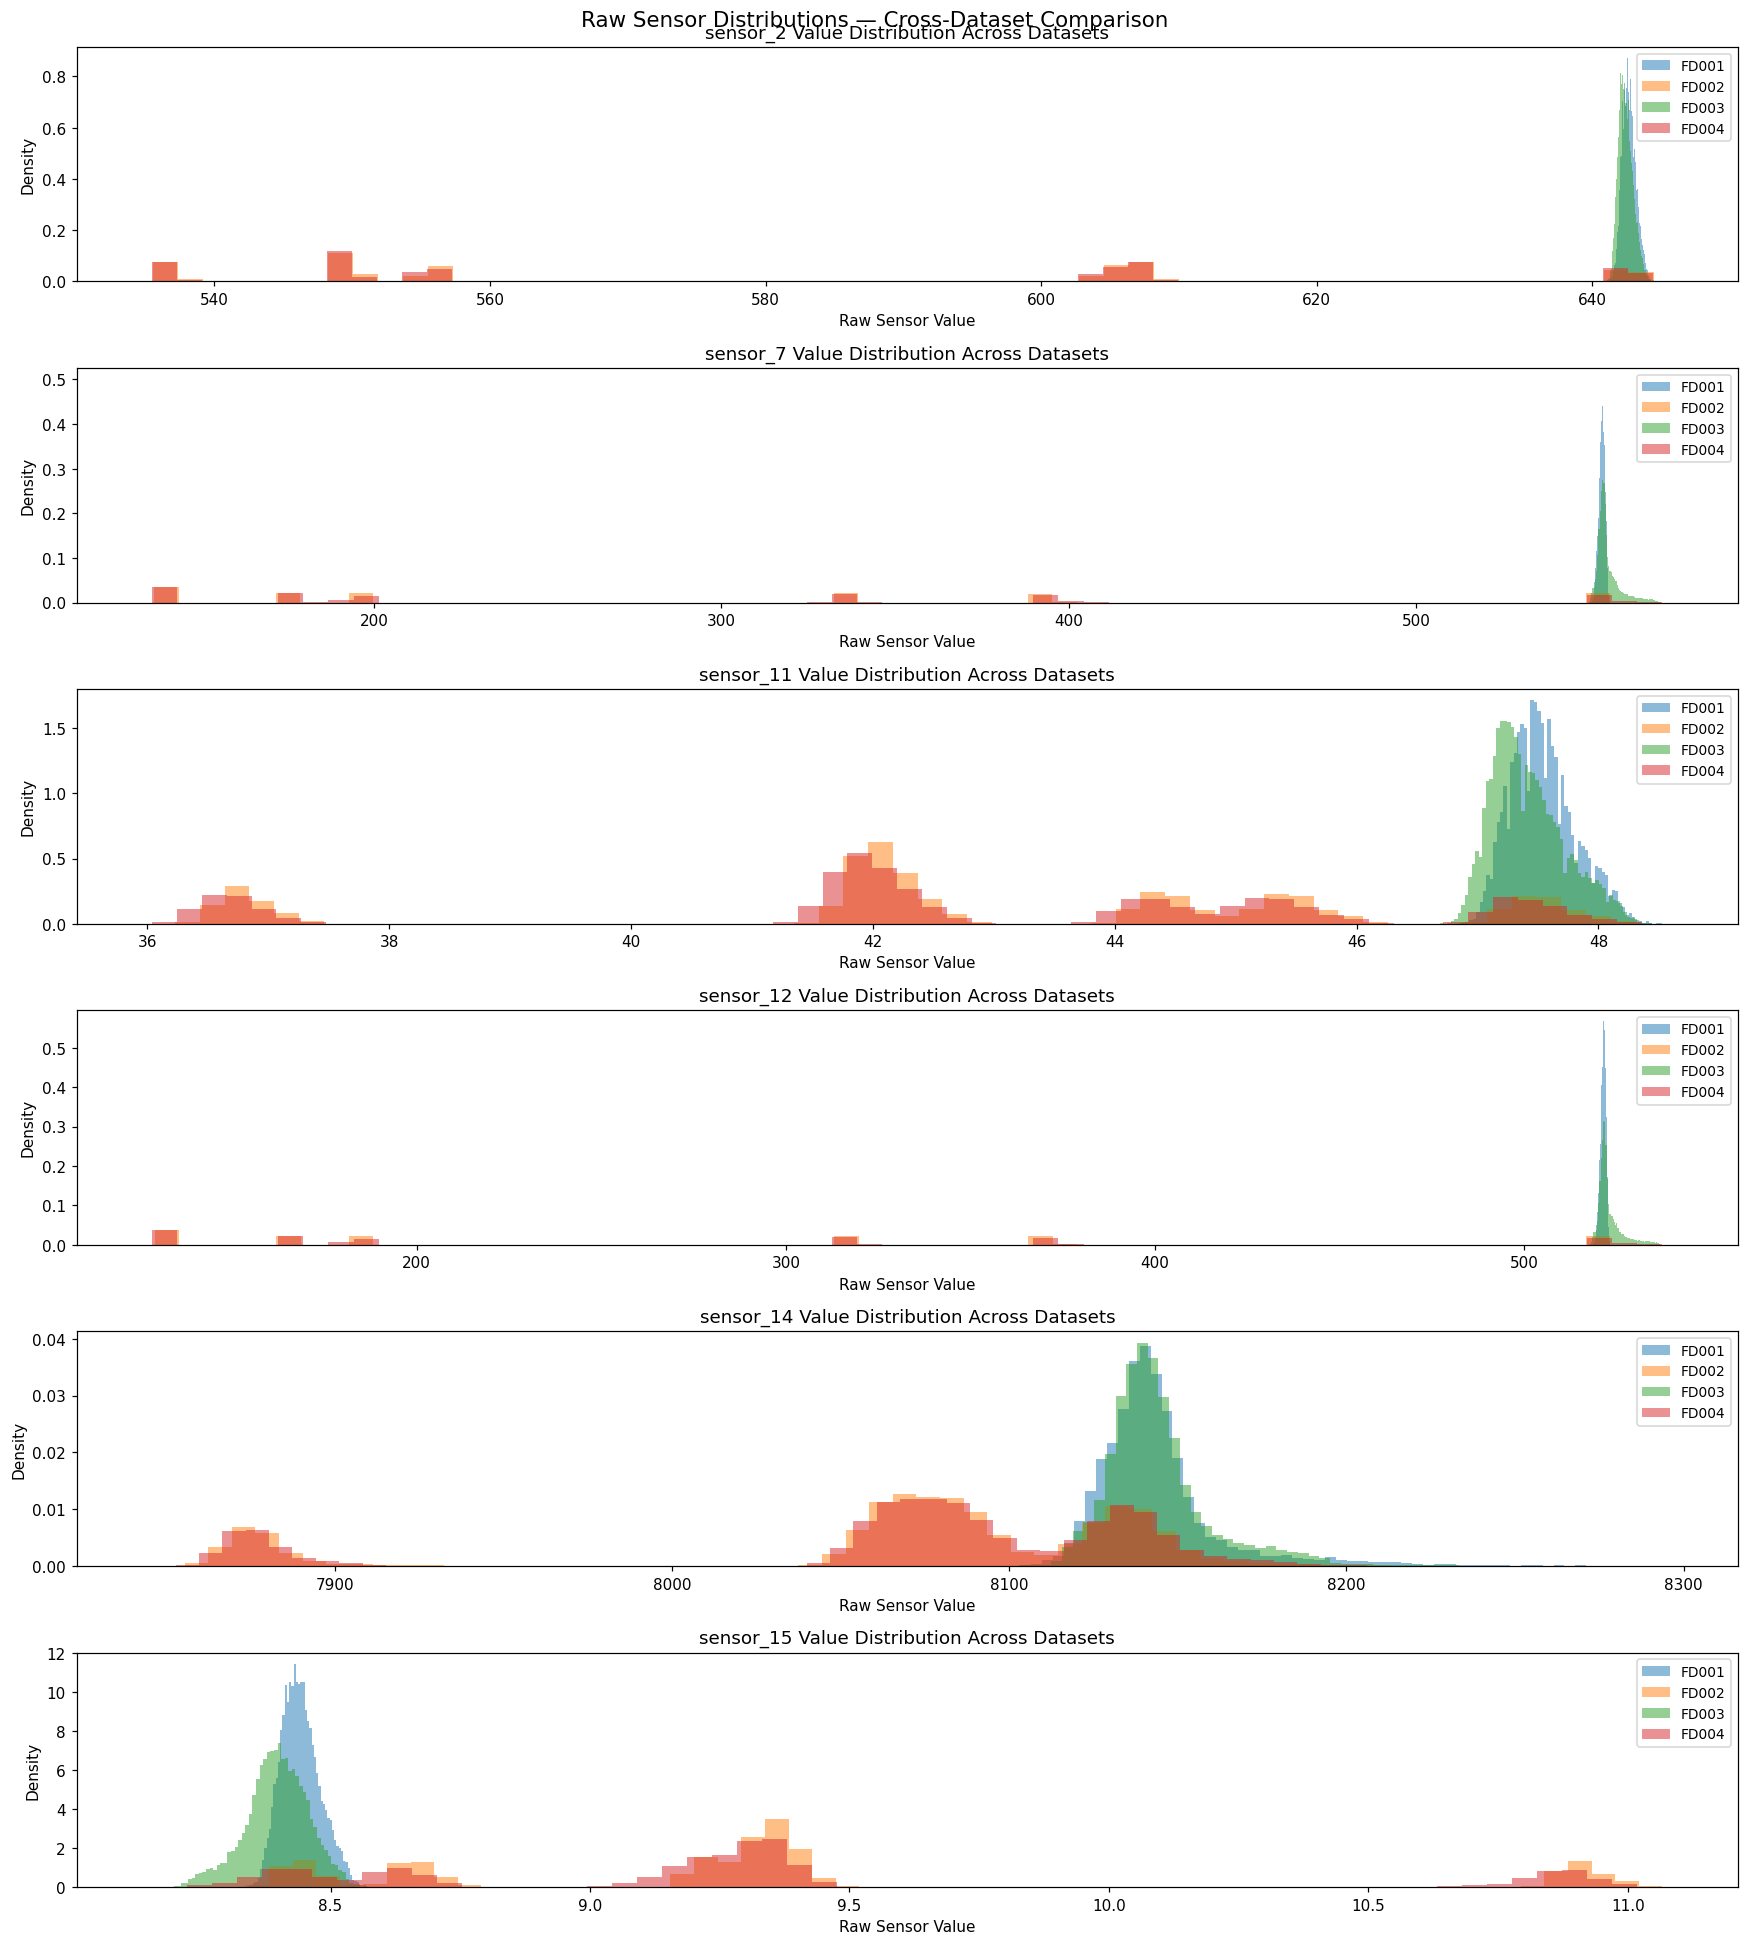

In [ ]:
sensors_to_compare = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_12',
                       'sensor_14', 'sensor_15']

fig, axes = plt.subplots(len(sensors_to_compare), 1, figsize=(16, 3 * len(sensors_to_compare)))
colors = {'FD001': '#1f77b4', 'FD003': '#2ca02c'}

for ax, sensor in zip(axes, sensors_to_compare):
    for ds_id in SELECTED_DS:
        vals = datasets[ds_id]['train'][sensor].dropna()
        ax.hist(vals, bins=60, alpha=0.5, label=ds_id,
                color=colors[ds_id], density=True)
    ax.set_title(f'{sensor} Value Distribution (FD001 vs FD003)')
    ax.set_xlabel('Raw Sensor Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Raw Sensor Distributions — FD001 vs FD003', fontsize=14)
plt.tight_layout()
plt.show()


**Insight:** FD001 and FD003 show similar degradation-sensitive channels with
distribution shifts in magnitude and spread, supporting transfer-learning and
domain-adaptation evaluation on matched fault families.

## 1.4 Average Sensor Trend vs. Remaining Useful Life (FD001)

Align all engines at their end-of-life point to visualise how sensors
behave as failure approaches.


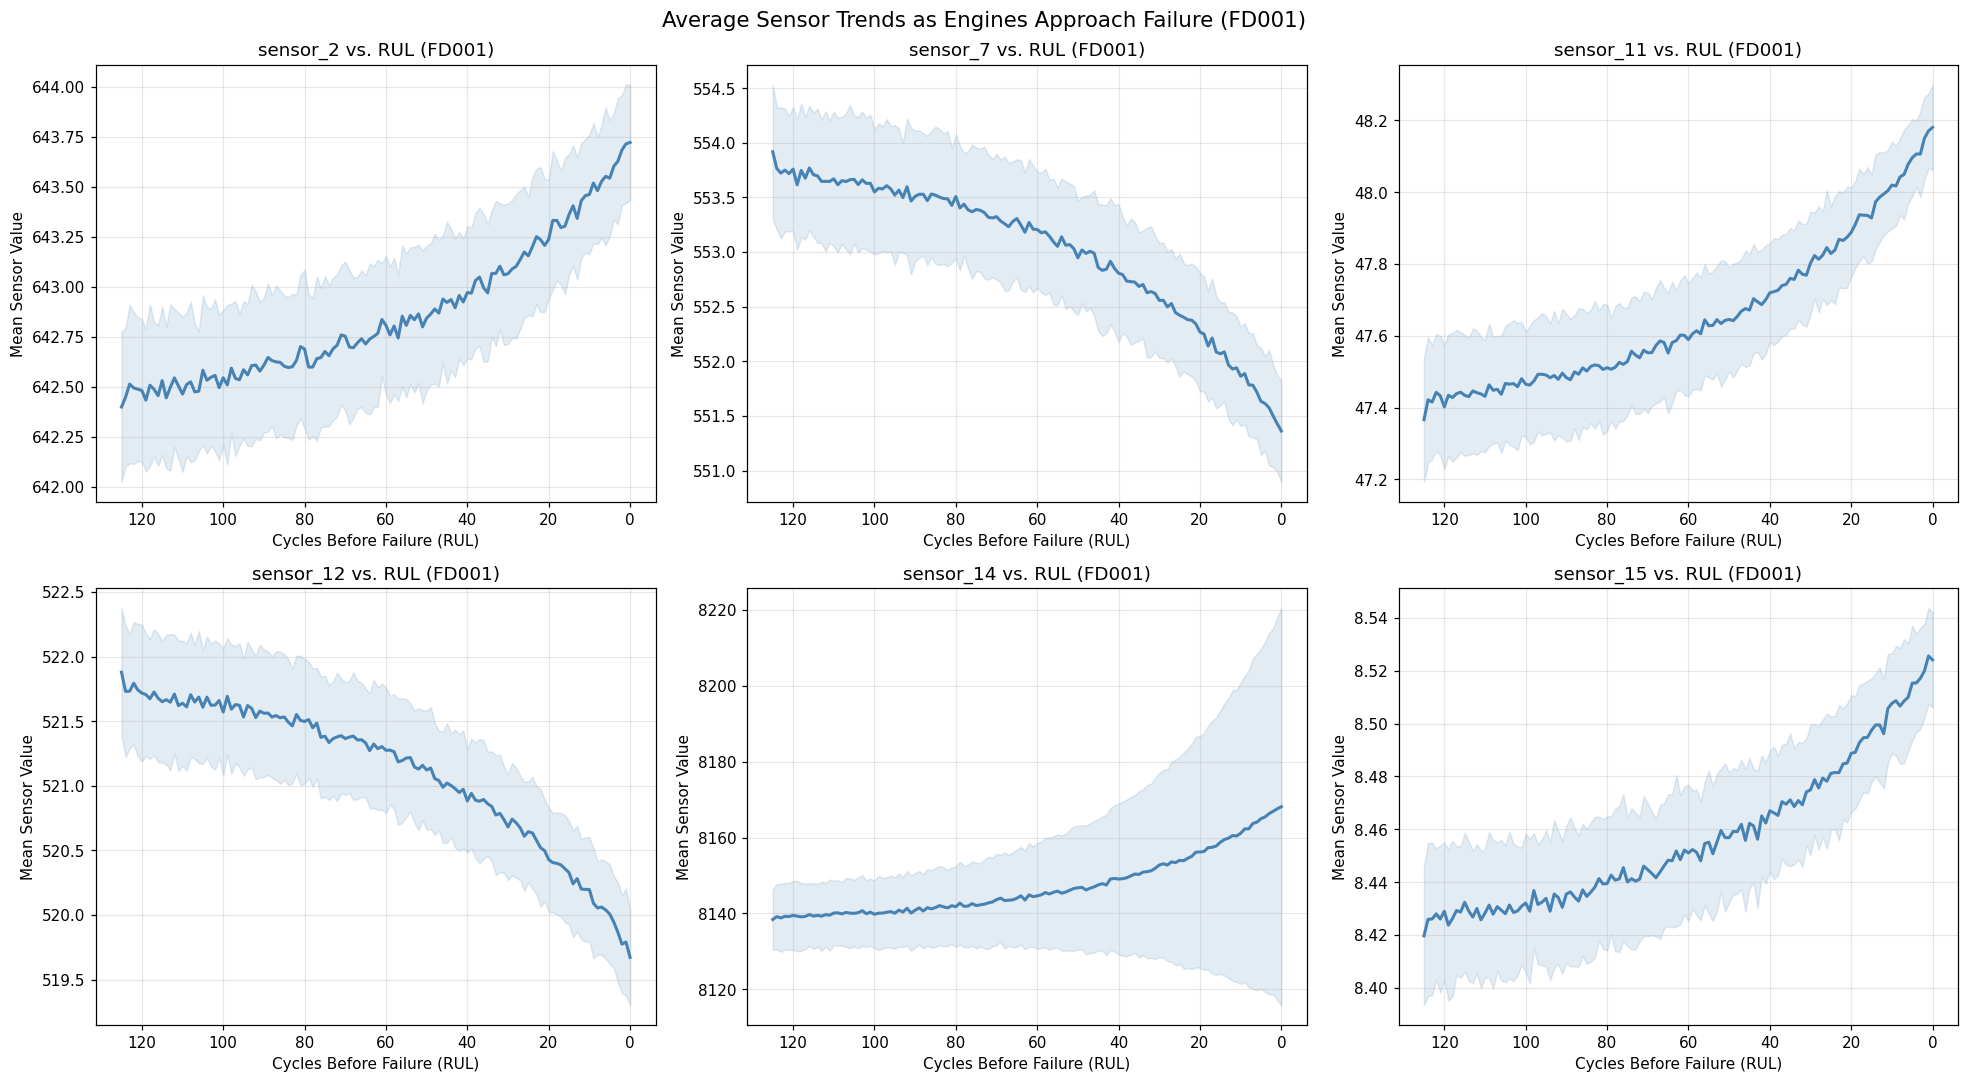

In [7]:
df_with_rul = add_piecewise_rul(datasets['FD001']['train'], max_rul=125)

sensors_to_plot = ['sensor_2', 'sensor_7', 'sensor_11',
                    'sensor_12', 'sensor_14', 'sensor_15']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, sensor in zip(axes.flatten(), sensors_to_plot):
    trend = df_with_rul.groupby('RUL')[sensor].mean()
    std   = df_with_rul.groupby('RUL')[sensor].std()
    ax.plot(trend.index, trend.values, color='steelblue', linewidth=2)
    ax.fill_between(trend.index,
                     trend.values - std.values,
                     trend.values + std.values,
                     alpha=0.15, color='steelblue')
    ax.invert_xaxis()
    ax.set_xlabel('Cycles Before Failure (RUL)')
    ax.set_ylabel('Mean Sensor Value')
    ax.set_title(f'{sensor} vs. RUL (FD001)')
    ax.grid(alpha=0.3)

plt.suptitle('Average Sensor Trends as Engines Approach Failure (FD001)', fontsize=14)
plt.tight_layout()
plt.show()


**Insight:** Sensors 11, 12, and 14 show clear monotonic trends as RUL
approaches zero — these are the primary degradation indicators in the
selected FD001/FD003 exploration scope. Sensor 7 and sensor 2 are noisier
but still carry predictive signal for downstream modeling.

## 1.5 Operating Condition Clustering (Skipped)

FD001 and FD003 are single-condition datasets. Per implementation plan,
multi-condition clustering analysis (FD002/FD004) is omitted in this notebook.

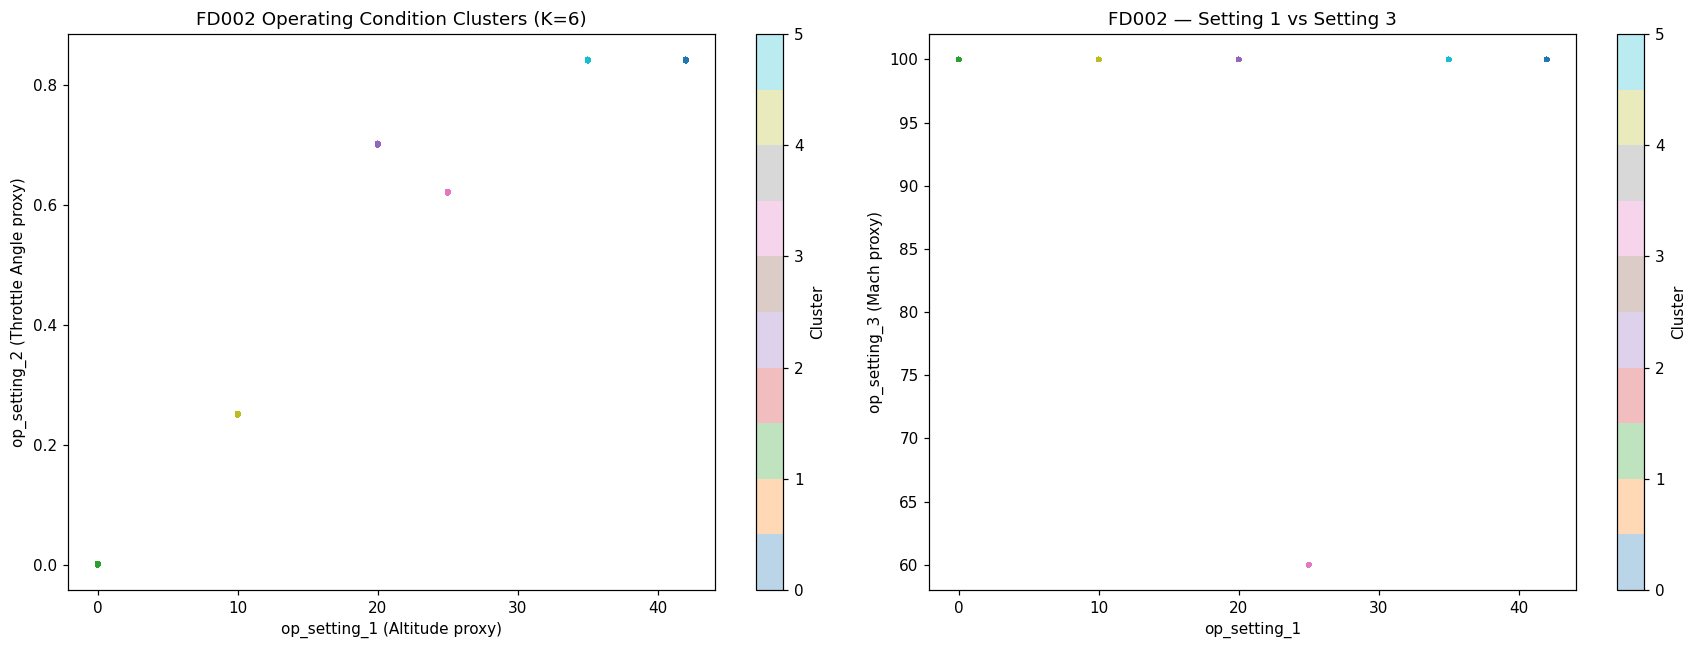

In [ ]:
print("Operating-condition clustering skipped:")
print("- FD001/FD003 are single-condition datasets")
print("- FD002/FD004 analysis removed per Step 4 scope")


**Insight:** Multi-condition clustering is intentionally excluded here.
The notebook now focuses on single-condition FD001/FD003 behavior and the
cross-domain gap versus AI4I, which directly supports ADA motivation.

## 1.6 Per-Unit RUL Profile: Visualising Piecewise Linear Targets


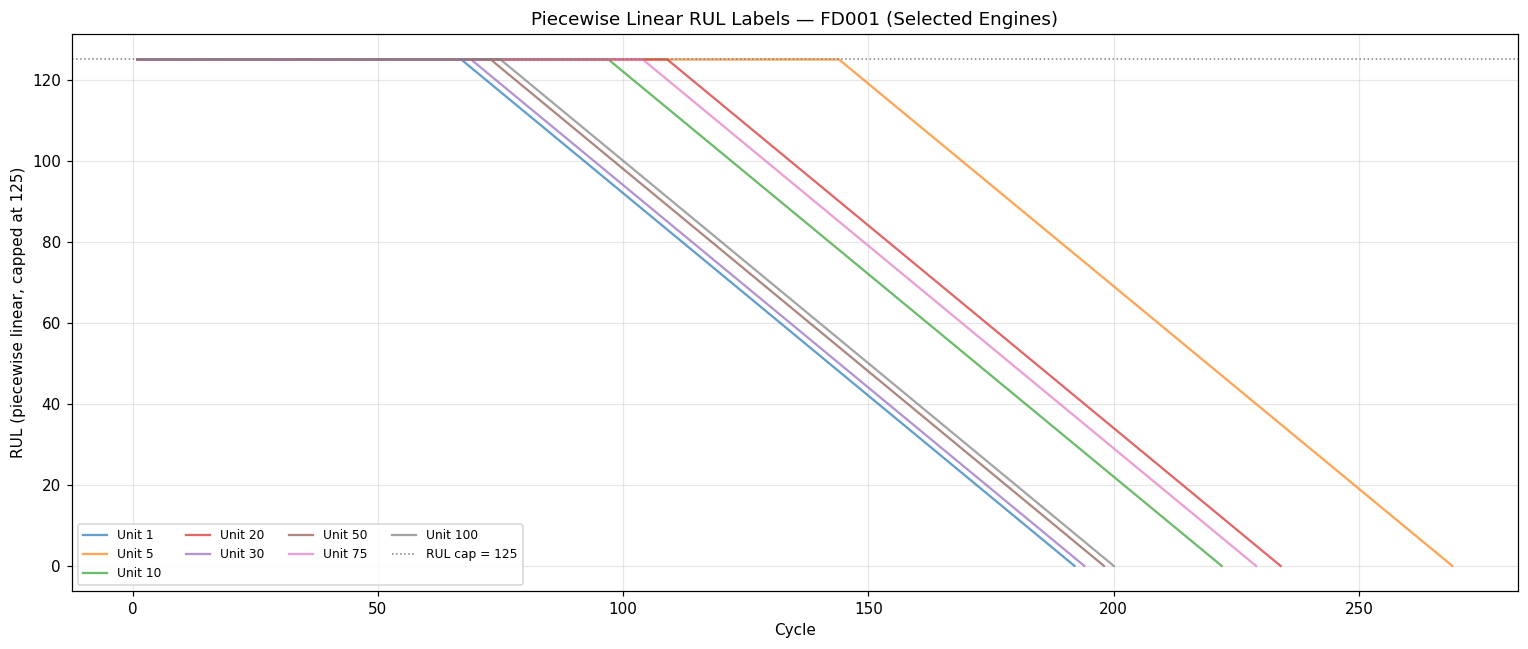

In [9]:
df_rul_plot = add_piecewise_rul(datasets['FD001']['train'], max_rul=125)
sample_units = [1, 5, 10, 20, 30, 50, 75, 100]

fig, ax = plt.subplots(figsize=(14, 6))
for unit in sample_units:
    ud = df_rul_plot[df_rul_plot['unit_id'] == unit]
    ax.plot(ud['cycle'], ud['RUL'], alpha=0.7, label=f'Unit {unit}')
ax.axhline(125, color='gray', linestyle=':', linewidth=1, label='RUL cap = 125')
ax.set_xlabel('Cycle')
ax.set_ylabel('RUL (piecewise linear, capped at 125)')
ax.set_title('Piecewise Linear RUL Labels — FD001 (Selected Engines)')
ax.legend(ncol=4, fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Insight:** The piecewise linear target treats all engines as equally healthy
during the flat phase (RUL = 125) then assigns linearly decreasing RUL.
The flat region length varies per unit because some engines start degrading
earlier than others, but all degrade monotonically once past the inflection point.


## 1.7 AI4I Dataset Loading & Basic Stats

This section adds the target-domain exploration required by Step 4.

In [2]:
# ── CELL: AI4I Dataset Loading & Basic Stats ──────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load AI4I 2020 dataset
# Source used in Step 3 acquisition: data/raw/ai4i2020.csv
ai4i = pd.read_csv('../data/raw/ai4i2020.csv')

print("AI4I Dataset Shape:", ai4i.shape)
print("\nColumns:", ai4i.columns.tolist())
print("\nFirst 5 rows:")
ai4i.head()

AI4I Dataset Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

First 5 rows:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
# ── CELL: AI4I Feature Overview ───────────────────────────────────────────────
print("=== AI4I 2020 Dataset Overview ===")
print(f"\nTotal rows: {len(ai4i)}")
print(f"Failure rate: {ai4i['Machine failure'].mean():.2%}")

print(f"\nFailure mode breakdown:")
for col in ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']:
    if col in ai4i.columns:
        print(f"  {col}: {ai4i[col].sum()} failures ({ai4i[col].mean():.2%})")

print(f"\nProduct quality types:")
print(ai4i['Type'].value_counts())

print(f"\nSensor statistics:")
sensor_cols_ai4i = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
print(ai4i[sensor_cols_ai4i].describe().round(2))

=== AI4I 2020 Dataset Overview ===

Total rows: 10000
Failure rate: 3.39%

Failure mode breakdown:
  TWF: 46 failures (0.46%)
  HDF: 115 failures (1.15%)
  PWF: 95 failures (0.95%)
  OSF: 98 failures (0.98%)
  RNF: 19 failures (0.19%)

Product quality types:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Sensor statistics:
       Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
count              10000.0                 10000.00                10000.00   
mean                 300.0                   310.01                 1538.78   
std                    2.0                     1.48                  179.28   
min                  295.3                   305.70                 1168.00   
25%                  298.3                   308.80                 1423.00   
50%                  300.1                   310.10                 1503.00   
75%                  301.5                   311.10                 1612.00   
max                  304.5  

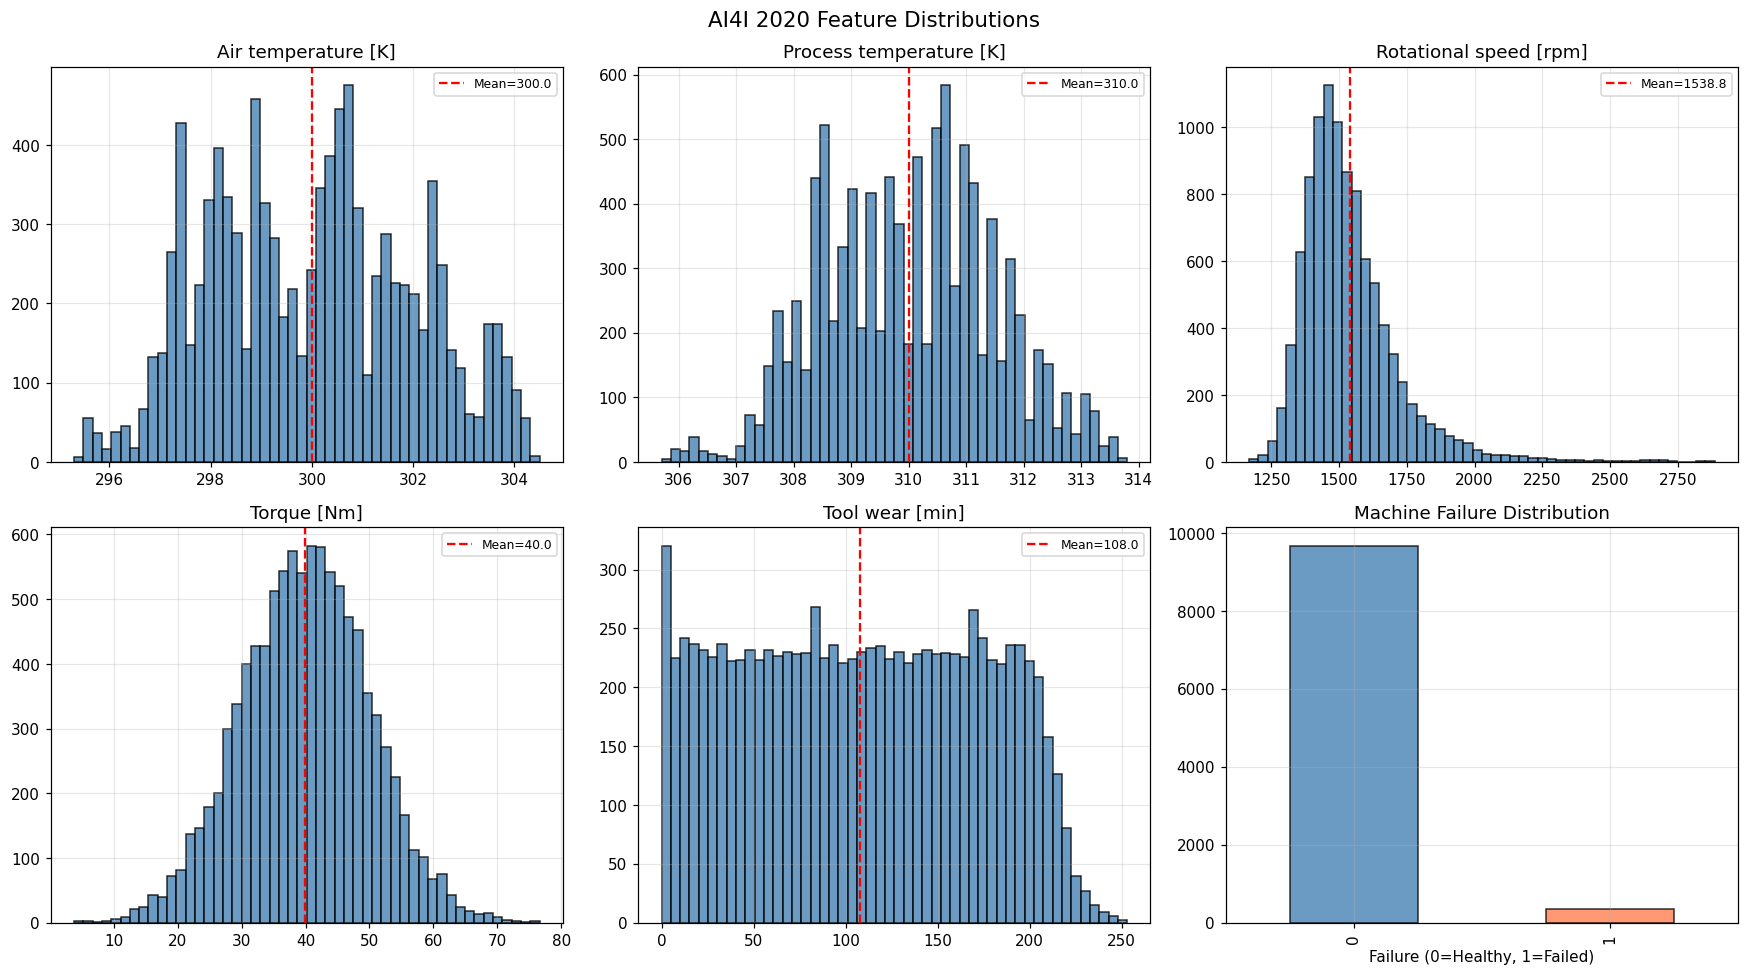

In [4]:
# ── CELL: AI4I Sensor Distribution Plots ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), sensor_cols_ai4i + ['Machine failure']):
    if col == 'Machine failure':
        ai4i[col].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'],
                                      edgecolor='black', alpha=0.8)
        ax.set_title('Machine Failure Distribution')
        ax.set_xlabel('Failure (0=Healthy, 1=Failed)')
    else:
        ax.hist(ai4i[col], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
        ax.axvline(ai4i[col].mean(), color='red', linestyle='--', linewidth=1.5,
                   label=f"Mean={ai4i[col].mean():.1f}")
        ax.set_title(f'{col}')
        ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('AI4I 2020 Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

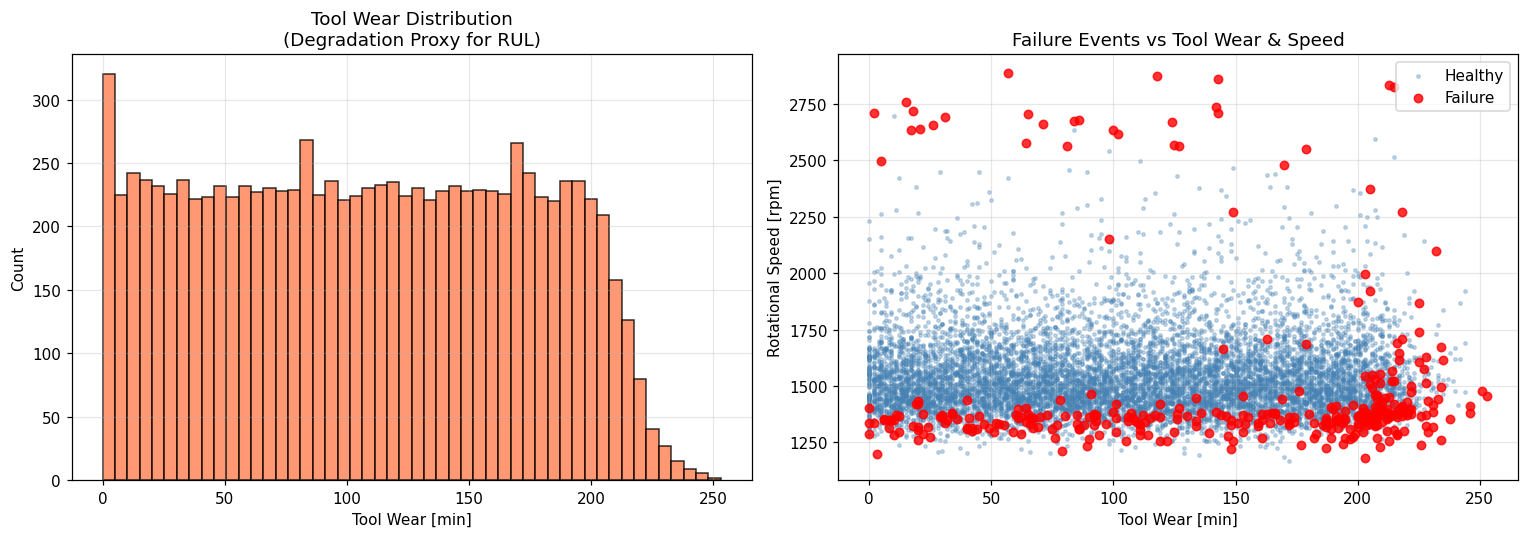


Max tool wear before failure: 253.0 min
Mean tool wear at failure: 143.8 min


In [5]:
# ── CELL: AI4I Tool Wear as RUL Proxy ────────────────────────────────────────
# Tool wear [min] increases monotonically until failure — analogous to degradation proxy.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tool wear distribution
axes[0].hist(ai4i['Tool wear [min]'], bins=50, color='coral',
             edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Tool Wear [min]')
axes[0].set_ylabel('Count')
axes[0].set_title('Tool Wear Distribution\n(Degradation Proxy for RUL)')
axes[0].grid(alpha=0.3)

# Tool wear vs failure
failure_mask = ai4i['Machine failure'] == 1
axes[1].scatter(ai4i.loc[~failure_mask, 'Tool wear [min]'],
                ai4i.loc[~failure_mask, 'Rotational speed [rpm]'],
                alpha=0.3, s=5, color='steelblue', label='Healthy')
axes[1].scatter(ai4i.loc[failure_mask, 'Tool wear [min]'],
                ai4i.loc[failure_mask, 'Rotational speed [rpm]'],
                alpha=0.8, s=30, color='red', label='Failure', zorder=5)
axes[1].set_xlabel('Tool Wear [min]')
axes[1].set_ylabel('Rotational Speed [rpm]')
axes[1].set_title('Failure Events vs Tool Wear & Speed')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMax tool wear before failure: {ai4i.loc[failure_mask, 'Tool wear [min]'].max():.1f} min")
print(f"Mean tool wear at failure: {ai4i.loc[failure_mask, 'Tool wear [min]'].mean():.1f} min")

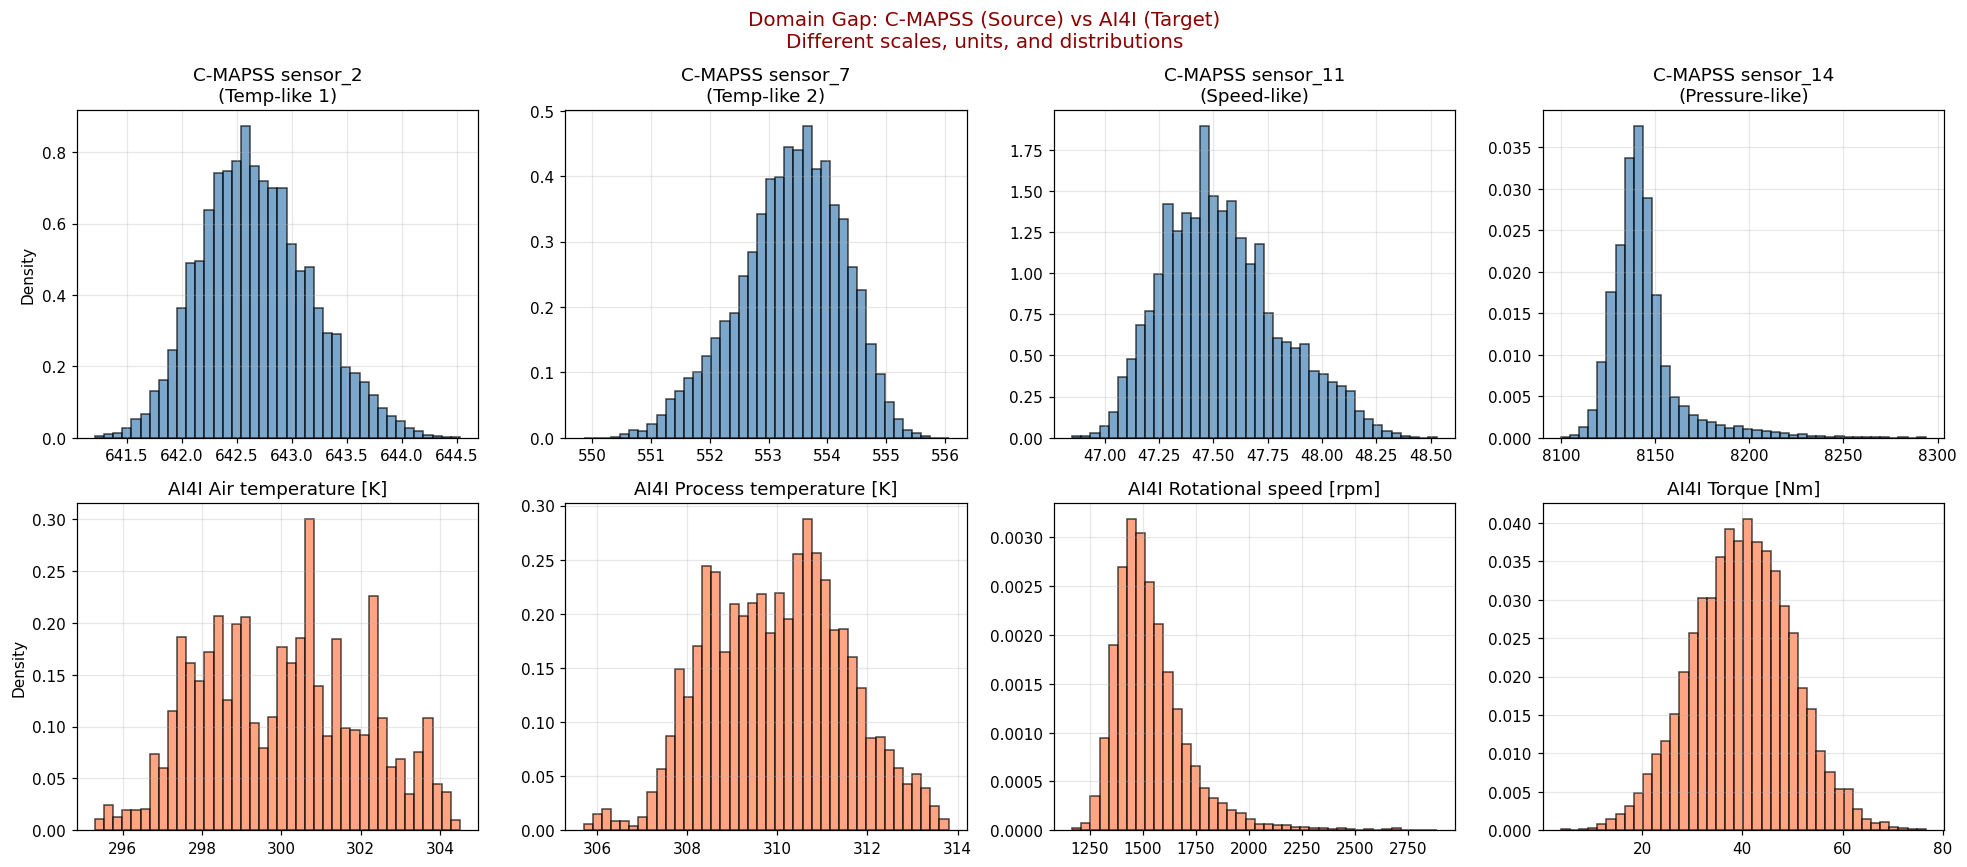


This is why Domain Adversarial training is needed:
raw source and target features are not directly comparable.


In [6]:
# ── CELL: Domain Gap Visualisation (C-MAPSS vs AI4I) ─────────────────────────
# Key motivation for DANN: different sensor scales/types/distributions.
df_fd001 = datasets['FD001']['train']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
cmapss_sensors = ['sensor_2', 'sensor_7', 'sensor_11', 'sensor_14']
ai4i_sensors = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]']
titles = ['Temp-like 1', 'Temp-like 2', 'Speed-like', 'Pressure-like']

for i, (cs, as_, title) in enumerate(zip(cmapss_sensors, ai4i_sensors, titles)):
    axes[0, i].hist(df_fd001[cs], bins=40, color='steelblue', alpha=0.7,
                    edgecolor='black', density=True)
    axes[0, i].set_title(f'C-MAPSS {cs}\n({title})')
    axes[0, i].set_ylabel('Density' if i == 0 else '')
    axes[0, i].grid(alpha=0.3)

    axes[1, i].hist(ai4i[as_], bins=40, color='coral', alpha=0.7,
                    edgecolor='black', density=True)
    axes[1, i].set_title(f'AI4I {as_}')
    axes[1, i].set_ylabel('Density' if i == 0 else '')
    axes[1, i].grid(alpha=0.3)

plt.suptitle('Domain Gap: C-MAPSS (Source) vs AI4I (Target)\n'
             'Different scales, units, and distributions',
             fontsize=13, color='darkred')
plt.tight_layout()
plt.show()

print("\nThis is why Domain Adversarial training is needed:")
print("raw source and target features are not directly comparable.")